# Аудит сырых данных

Проверяем качество корпуса до сборки train/val/test-сплитов. Данные лежат в `data/human/`, `data/gen/`, `data/adversarial/`. Всё что найдём - учтём в `assemble_dataset.py`.

## Окружение и стиль

In [1]:
import hashlib
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

# цвета
sns.set_theme(style="whitegrid", font_scale=1.1)

C_HUMAN = "#4C72B0"
C_AI    = "#DD8452"
C_ADV   = "#55A868"
C_ALERT = "#C44E52"
C_WARN  = "#F0A202"
PAL_DOMAIN = sns.color_palette("Set2", 3)

plt.rcParams.update({
    "figure.dpi": 130, "figure.facecolor": "white",
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 11, "font.size": 10,
    "legend.fontsize": 9, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
})

# пути
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"

## Загрузка данных

In [ ]:
def load_jsonl(path: Path) -> pd.DataFrame:
    df = pd.read_json(path, lines=True, encoding_errors="replace")
    df["_file"] = path.name
    return df

# human
human_files = {
    "habr":  DATA_DIR / "human" / "habr_essays.jsonl",
    "taiga": DATA_DIR / "human" / "taiga_nplus1_with_time.jsonl",
    "wiki":  DATA_DIR / "human" / "wiki_articles.jsonl",
}
human_dfs = {k: load_jsonl(p) for k, p in human_files.items()}

# AI-генерации
gen_dfs = {p.stem: load_jsonl(p) for p in sorted((DATA_DIR / "gen").glob("*.jsonl"))}

# adversarial
adv_dfs = {p.stem: load_jsonl(p) for p in sorted((DATA_DIR / "adversarial").glob("*.jsonl"))}

# единый реестр (name -> df) для итераций
all_named_dfs = (
    [(f"human/{k}", v) for k, v in human_dfs.items()]
    + [(f"gen/{k}", v) for k, v in gen_dfs.items()]
    + [(f"adv/{k}", v) for k, v in adv_dfs.items()]
)

# сводка
rows = []
for grp, store in [("human", human_dfs), ("gen", gen_dfs), ("adv", adv_dfs)]:
    for name, df in store.items():
        rows.append({"группа": grp, "файл": name, "строк": len(df), "колонок": df.shape[1]})
pd.DataFrame(rows)

,группа,файл,строк,колонок
0,human,habr,4000,8
1,human,taiga,6749,9
2,human,wiki,4781,8
3,gen,gemini-2.5-flash-lite_essay,913,8
4,gen,gemini-2.5-flash-lite_news,992,8
5,gen,gemini-2.5-flash-lite_wiki,957,8
6,gen,GigaChat_essay,2000,8
7,gen,GigaChat_news,1999,8
8,gen,GigaChat_wiki,2000,8
9,gen,llama-3.3-70b-versatile_essay,1000,8


## Схема данных

Проверим, что каждый источник содержит `text`, `label`, `domain`, `source_name`, `doc_id`.

In [3]:
REQUIRED = {"text", "label", "domain", "source_name", "doc_id"}

report = []
for name, df in all_named_dfs:
    cols = set(df.columns) - {"_file"}
    report.append({
        "источник": name,
        "нет": ", ".join(sorted(REQUIRED - cols)) or "-",
        "лишние": ", ".join(sorted(cols - REQUIRED)) or "-",
    })

schema_df = pd.DataFrame(report)

schema_df

,источник,нет,лишние
0,human/habr,-,"created_at, meta"
1,human/taiga,-,"created_at, group_id, meta"
2,human/wiki,-,"created_at, group_id"
3,gen/gemini-2.5-flash-lite_essay,-,"created_at, meta"
4,gen/gemini-2.5-flash-lite_news,-,"created_at, meta"
5,gen/gemini-2.5-flash-lite_wiki,-,"created_at, meta"
6,gen/GigaChat_essay,-,"created_at, meta"
7,gen/GigaChat_news,-,"created_at, meta"
8,gen/GigaChat_wiki,-,"created_at, meta"
9,gen/llama-3.3-70b-versatile_essay,-,"created_at, meta"


Adversarial-файлы содержат `source_model`, которого нет в остальных; habr хранит `created_at` и `meta`; taiga/wiki - `group_id`. Расхождения в опциональных полях ожидаемы, тут всё нормально.

### Словарь колонок

In [ ]:
EXPECTED_COLUMNS = {
    "text":        "текст (вход модели)",
    "label":       "целевая метка (human / ai)",
    "domain":      "домен (essay / news / wiki)",
    "source_name": "источник / модель-генератор",
    "doc_id":      "уникальный ID документа",
    "created_at":  "дата создания (может быть null)",
    "meta":        "метаданные генерации (prompt_id, topic, temperature …)",
}

combined = pd.concat([df for _, df in all_named_dfs], ignore_index=True)
actual = set(combined.columns) - {"_file"}

present = [c for c in EXPECTED_COLUMNS if c in actual]
extra   = sorted(actual - set(EXPECTED_COLUMNS))

print(f"Ожидаемых: {len(present)}/{len(EXPECTED_COLUMNS)}")
if extra:
    print(f"Дополнительные: {extra}")
print()
for col, desc in EXPECTED_COLUMNS.items():
    mark = "yes" if col in actual else "no"
    print(f"{mark} {col:15s} --- {desc}")

Ожидаемых: 7/7
Дополнительные: ['group_id', 'source_model']

  yes text            --- текст (вход модели)
  yes label           --- целевая метка (human / ai)
  yes domain          --- домен (essay / news / wiki)
  yes source_name     --- источник / модель-генератор
  yes doc_id          --- уникальный ID документа
  yes created_at      --- дата создания (может быть null)
  yes meta            --- метаданные генерации (prompt_id, topic, temperature …)


## Полнота данных

In [ ]:
CRITICAL = ["text", "label", "domain", "source_name"]

rows = []
for name, df in all_named_dfs:
    row = {"источник": name}
    for col in CRITICAL:
        if col not in df.columns:
            row[f"{col}_null"] = "N/A"
            row[f"{col}_empty"] = "N/A"
            continue
        row[f"{col}_null"] = int(df[col].isna().sum())
        row[f"{col}_empty"] = (int((df[col].fillna("").str.strip() == "").sum())
            if df[col].dtype == object else 0
        )
    rows.append(row)

comp_df = pd.DataFrame(rows)
val_cols = [c for c in comp_df.columns if c != "источник"]
has_issue = comp_df[val_cols].apply(pd.to_numeric, errors="coerce").fillna(0).gt(0).any(axis=1)

has_issue.any()
print(comp_df[has_issue].to_string(index=False))

Empty DataFrame
Columns: [источник, text_null, text_empty, label_null, label_empty, domain_null, domain_empty, source_name_null, source_name_empty]
Index: []


## Целостность меток

In [ ]:
for group_name, store in [("Human", human_dfs), ("Gen", gen_dfs), ("Adv", adv_dfs)]:
    print(f"=== {group_name} ===")
    for name, df in store.items():
        vals = df["label"].unique().tolist()
        dtype = df["label"].dtype
        print(f"{name}: {vals} ({dtype})")
    print()

=== Human ===
  habr: ['human']  (str)
  taiga: ['human']  (str)
  wiki: ['human']  (str)

=== Gen ===
  gemini-2.5-flash-lite_essay: ['ai']  (str)
  gemini-2.5-flash-lite_news: ['ai']  (str)
  gemini-2.5-flash-lite_wiki: ['ai']  (str)
  GigaChat_essay: ['ai']  (str)
  GigaChat_news: ['ai']  (str)
  GigaChat_wiki: ['ai']  (str)
  llama-3.3-70b-versatile_essay: ['ai']  (str)
  llama-3.3-70b-versatile_news: ['ai']  (str)
  llama-3.3-70b-versatile_wiki: ['ai']  (str)
  yandexgpt-lite_essay: ['ai']  (str)
  yandexgpt-lite_news: ['ai']  (str)
  yandexgpt-lite_wiki: ['ai']  (str)
  yandexgpt_essay: ['ai']  (str)
  yandexgpt_news: ['ai']  (str)
  yandexgpt_wiki: ['ai']  (str)

=== Adv ===
  adversarial_paraphrase_GigaChat: [1]  (int64)
  adversarial_paraphrase_yandexgpt-lite: [1]  (int64)



При сборке `assemble_dataset.py` нужно привести adversarial-метки к `"ai"`, иначе стратифицированное разбиение сломается.

note: добавить assert на типы меток после конвертации

## Дубликаты

In [7]:
def text_hash(t: str) -> str:
    """MD5 от нормализованного текста lowercase, коллапс пробелов"""
    return hashlib.md5(re.sub(r"\s+", " ", str(t).lower().strip()).encode()).hexdigest()

for _, df in all_named_dfs:
    df["_hash"] = df["text"].apply(text_hash)

In [8]:
# проверка уникальности doc_id внутри каждого источника
for name, df_src in all_named_dfs:
    n_total = len(df_src)
    n_unique = df_src["doc_id"].nunique()
    dupes = n_total - n_unique
    if dupes > 0:
        print(f"{name}: {dupes} дублей doc_id из {n_total}")
    else:
        print(f"{name}: doc_id уникальны ({n_total})")


human/habr: doc_id уникальны (4000)
human/taiga: doc_id уникальны (6749)
human/wiki: doc_id уникальны (4781)
gen/gemini-2.5-flash-lite_essay: doc_id уникальны (913)
gen/gemini-2.5-flash-lite_news: doc_id уникальны (992)
gen/gemini-2.5-flash-lite_wiki: doc_id уникальны (957)
gen/GigaChat_essay: doc_id уникальны (2000)
gen/GigaChat_news: doc_id уникальны (1999)
gen/GigaChat_wiki: doc_id уникальны (2000)
gen/llama-3.3-70b-versatile_essay: doc_id уникальны (1000)
gen/llama-3.3-70b-versatile_news: doc_id уникальны (999)
gen/llama-3.3-70b-versatile_wiki: doc_id уникальны (1000)
gen/yandexgpt-lite_essay: doc_id уникальны (3004)
gen/yandexgpt-lite_news: doc_id уникальны (2838)
gen/yandexgpt-lite_wiki: doc_id уникальны (3000)
gen/yandexgpt_essay: doc_id уникальны (999)
gen/yandexgpt_news: doc_id уникальны (949)
gen/yandexgpt_wiki: doc_id уникальны (1000)
adv/adversarial_paraphrase_GigaChat: doc_id уникальны (508)
adv/adversarial_paraphrase_yandexgpt-lite: doc_id уникальны (8)


In [9]:
# внутри каждого источника
print("Дубликаты внутри источников:")
intra = 0
for name, df in all_named_dfs:
    n = df["_hash"].duplicated().sum()
    if n:
        print(f"  {name}: {n}")
        intra += n
if not intra:
    print("нет")

Дубликаты внутри источников:
  gen/GigaChat_essay: 4
  gen/GigaChat_news: 8
  gen/GigaChat_wiki: 8
  adv/adversarial_paraphrase_GigaChat: 3


In [10]:
# между источниками
combined_hashes = pd.concat(
    [df[["_hash", "source_name", "_file"]].assign(_group=name)
     for name, df in all_named_dfs],
    ignore_index=True,
)
cross = combined_hashes[combined_hashes.duplicated(subset="_hash", keep=False)]

if len(cross):
    groups = cross.groupby("_hash")["_group"].apply(set)
    cross_real = groups[groups.apply(len) > 1]
    print(f"Пересечения между источниками: {len(cross_real)} уникальных текстов")
    if len(cross_real):
        print(cross_real.head(10).to_string())
else:
    print("Пересечений между источниками нет.")

Пересечения между источниками: 3 уникальных текстов
_hash
31e1e1a538a8fb5e7199ba0057f76772    {gen/GigaChat_wiki, gen/GigaChat_essay, adv/ad...
4ae95bf93bf17e77dd76edb73d3aa496    {gen/GigaChat_news, gen/GigaChat_wiki, adv/adv...
e5f9d28896ebf79b0817c573547a2bea    {gen/GigaChat_news, gen/GigaChat_wiki, gen/Gig...


### Cross-split leakage

Проверим пересечения между сплитами - актуально после запуска `assemble_dataset.py`.

In [ ]:
splits_dir = DATA_DIR / "splits"

if splits_dir.exists() and any(splits_dir.glob("*.jsonl")):
    from itertools import combinations

    split_store = {p.stem: pd.read_json(p, lines=True) for p in sorted(splits_dir.glob("*.jsonl"))}
    print(f"Сплиты: {list(split_store.keys())}")

    for s1, s2 in combinations(split_store, 2):
        t1 = set(split_store[s1]["text"].str.lower().str.strip())
        t2 = set(split_store[s2]["text"].str.lower().str.strip())
        overlap = t1 & t2
        status = f"LEAKAGE: {len(overlap)} текстов" if overlap else "чисто"
        print(f"{s1} - {s2}: {status}")

Сплиты: ['holdout_tm_unseen', 'holdout_unseen', 'test', 'test_tm', 'train', 'train_tm', 'val', 'val_tm']
  holdout_tm_unseen ↔ holdout_unseen: LEAKAGE: 1136 текстов
  holdout_tm_unseen ↔ test: LEAKAGE: 741 текстов
  holdout_tm_unseen ↔ test_tm: чисто
  holdout_tm_unseen ↔ train: LEAKAGE: 3672 текстов
  holdout_tm_unseen ↔ train_tm: чисто
  holdout_tm_unseen ↔ val: LEAKAGE: 451 текстов
  holdout_tm_unseen ↔ val_tm: чисто
  holdout_unseen ↔ test: чисто
  holdout_unseen ↔ test_tm: LEAKAGE: 175 текстов
  holdout_unseen ↔ train: чисто
  holdout_unseen ↔ train_tm: LEAKAGE: 864 текстов
  holdout_unseen ↔ val: чисто
  holdout_unseen ↔ val_tm: LEAKAGE: 120 текстов
  test ↔ test_tm: LEAKAGE: 616 текстов
  test ↔ train: чисто
  test ↔ train_tm: LEAKAGE: 547 текстов
  test ↔ val: чисто
  test ↔ val_tm: LEAKAGE: 64 текстов
  test_tm ↔ train: LEAKAGE: 538 текстов
  test_tm ↔ train_tm: чисто
  test_tm ↔ val: LEAKAGE: 81 текстов
  test_tm ↔ val_tm: чисто
  train ↔ train_tm: LEAKAGE: 2700 текстов
  tra

## Распределение длин

Распределения и выбросы по длине текстов.

In [12]:
for _, df in all_named_dfs:
    df["_len"] = df["text"].str.len()

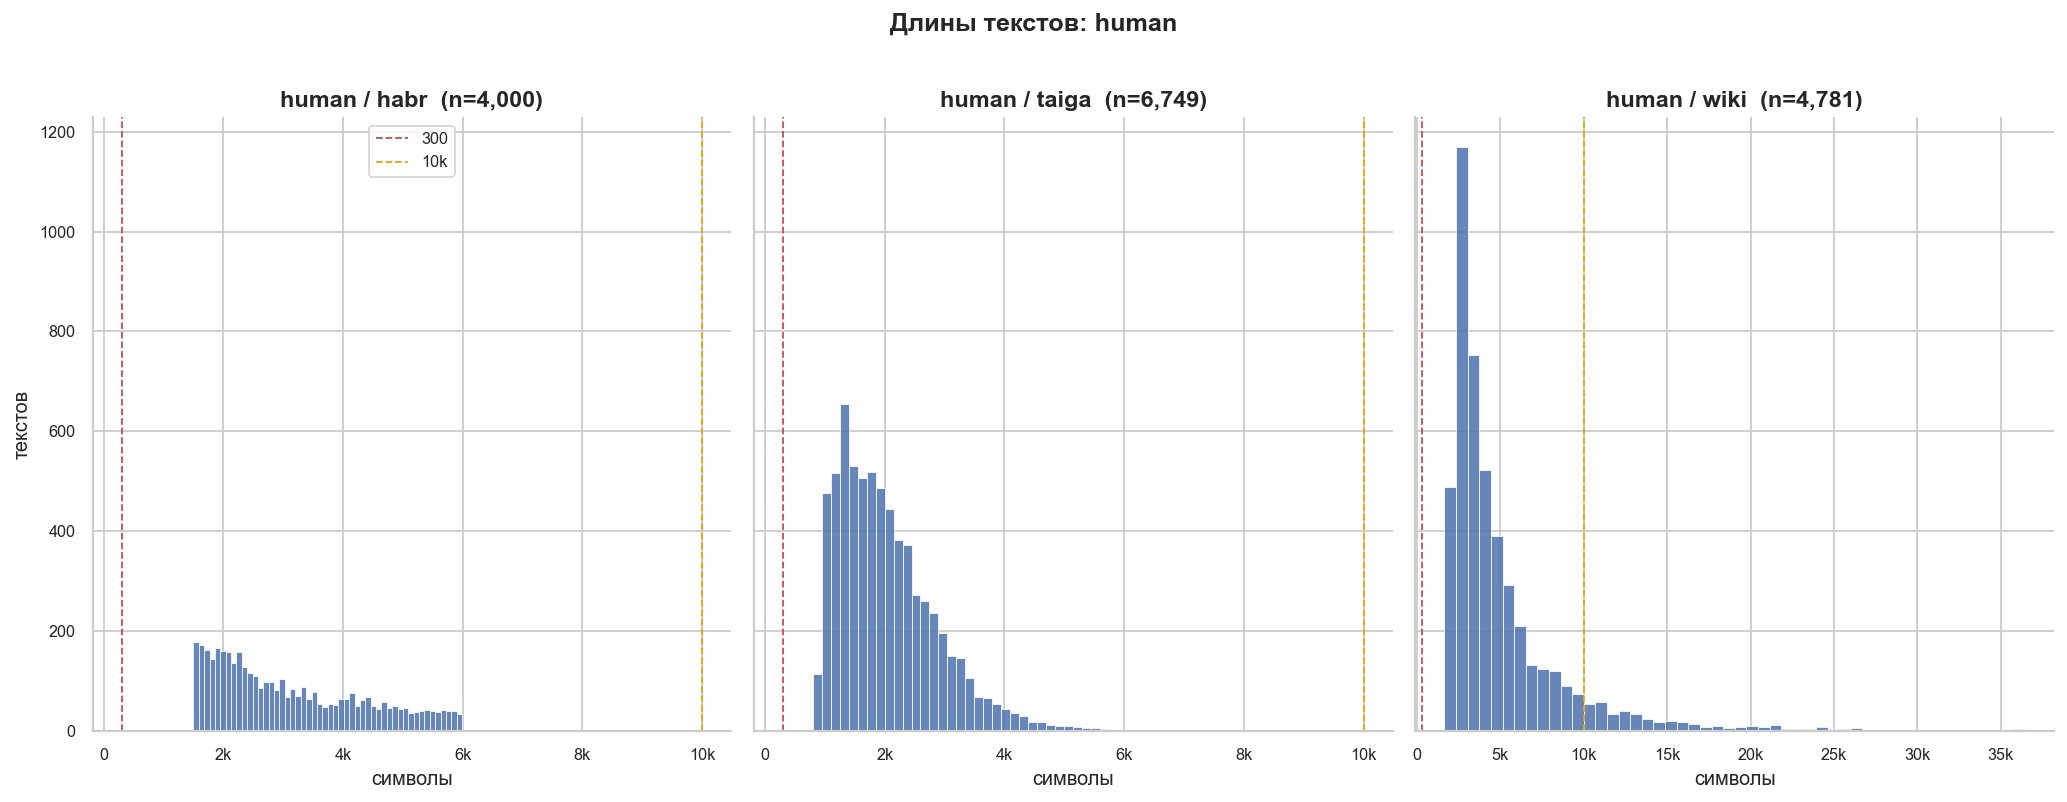

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

for ax, (name, df) in zip(axes, human_dfs.items()):
    ax.hist(df["_len"], bins=50, color=C_HUMAN, edgecolor="white", lw=.5, alpha=.85)
    ax.set_title(f"human / {name}  (n={len(df):,})")
    ax.set_xlabel("символы")
    ax.axvline(300,   color=C_ALERT, ls="--", lw=1, label="300")
    ax.axvline(10_000, color=C_WARN, ls="--", lw=1, label="10k")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k" if x >= 1e3 else f"{x:.0f}"))

axes[0].set_ylabel("текстов")
axes[0].legend(frameon=True)
fig.suptitle("Длины текстов: human", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

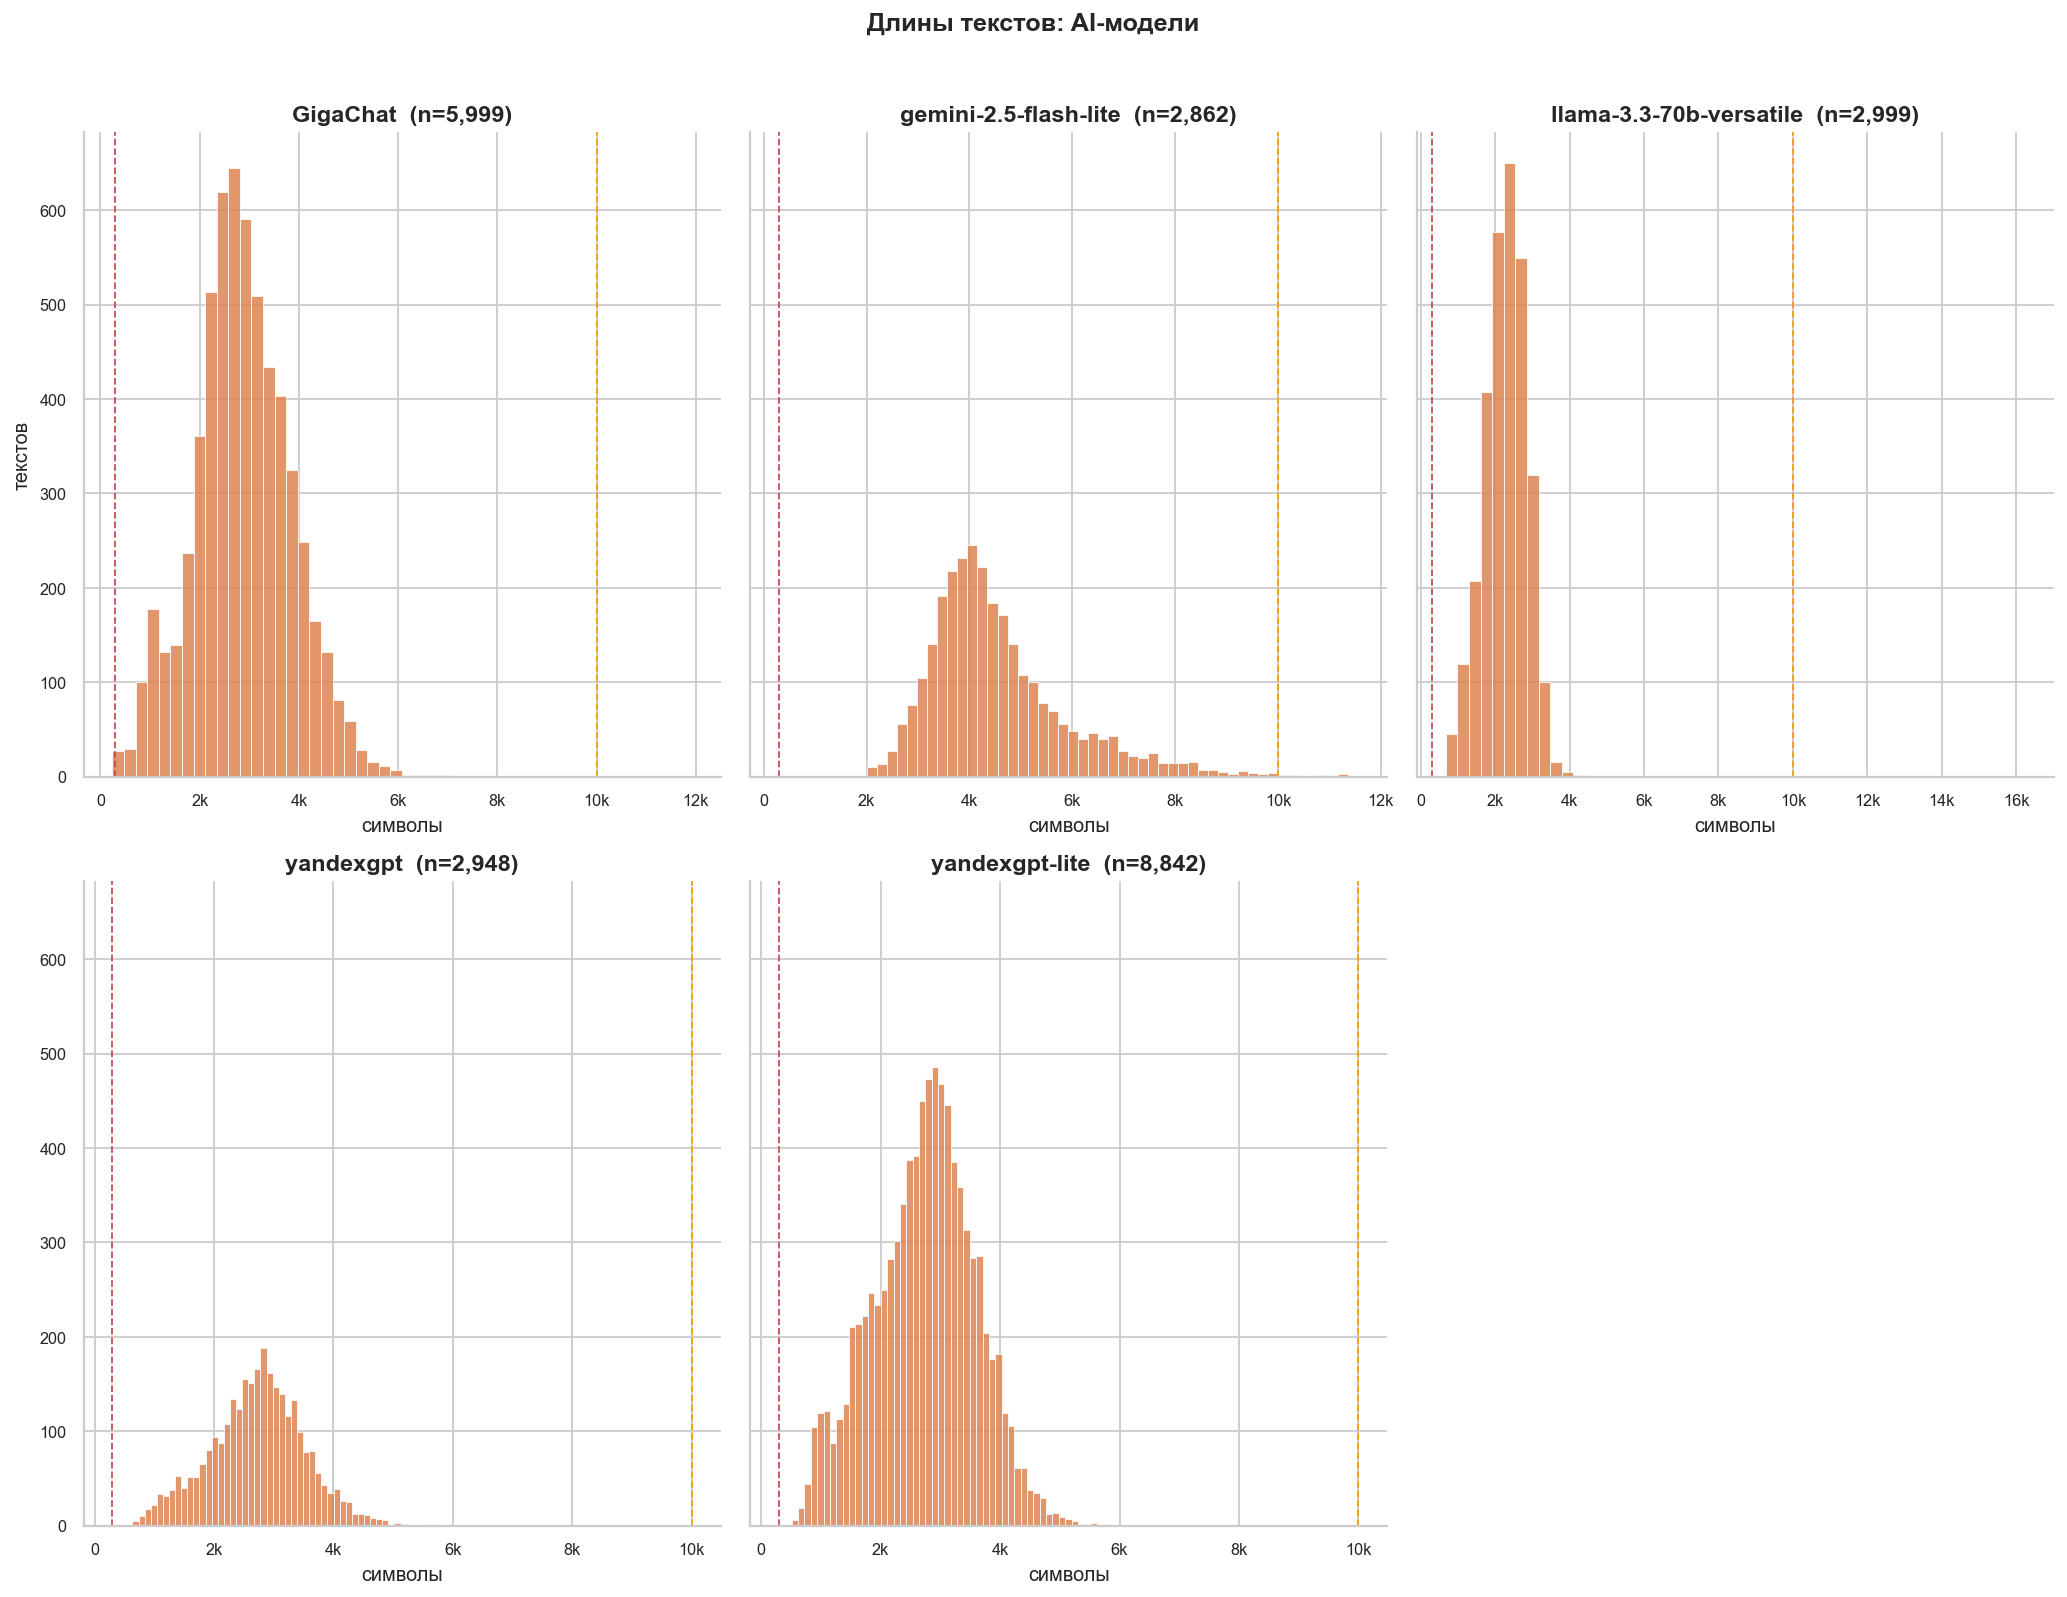

In [14]:
gen_all = pd.concat(gen_dfs.values(), ignore_index=True)
models = sorted(gen_all["source_name"].unique())

ncols = 3
nrows = -(-len(models) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 6 * nrows), sharey=True)
flat = axes.flatten()

for i, model in enumerate(models):
    ax = flat[i]
    sub = gen_all[gen_all["source_name"] == model]
    ax.hist(sub["_len"], bins=50, color=C_AI, edgecolor="white", lw=.5, alpha=.85)
    ax.set_title(f"{model}  (n={len(sub):,})")
    ax.set_xlabel("символы")
    ax.axvline(300,    color=C_ALERT, ls="--", lw=1)
    ax.axvline(10_000, color=C_WARN,  ls="--", lw=1)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k" if x >= 1e3 else f"{x:.0f}"))

for i in range(len(models), len(flat)):
    flat[i].set_visible(False)

flat[0].set_ylabel("текстов")
fig.suptitle("Длины текстов: AI-модели", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

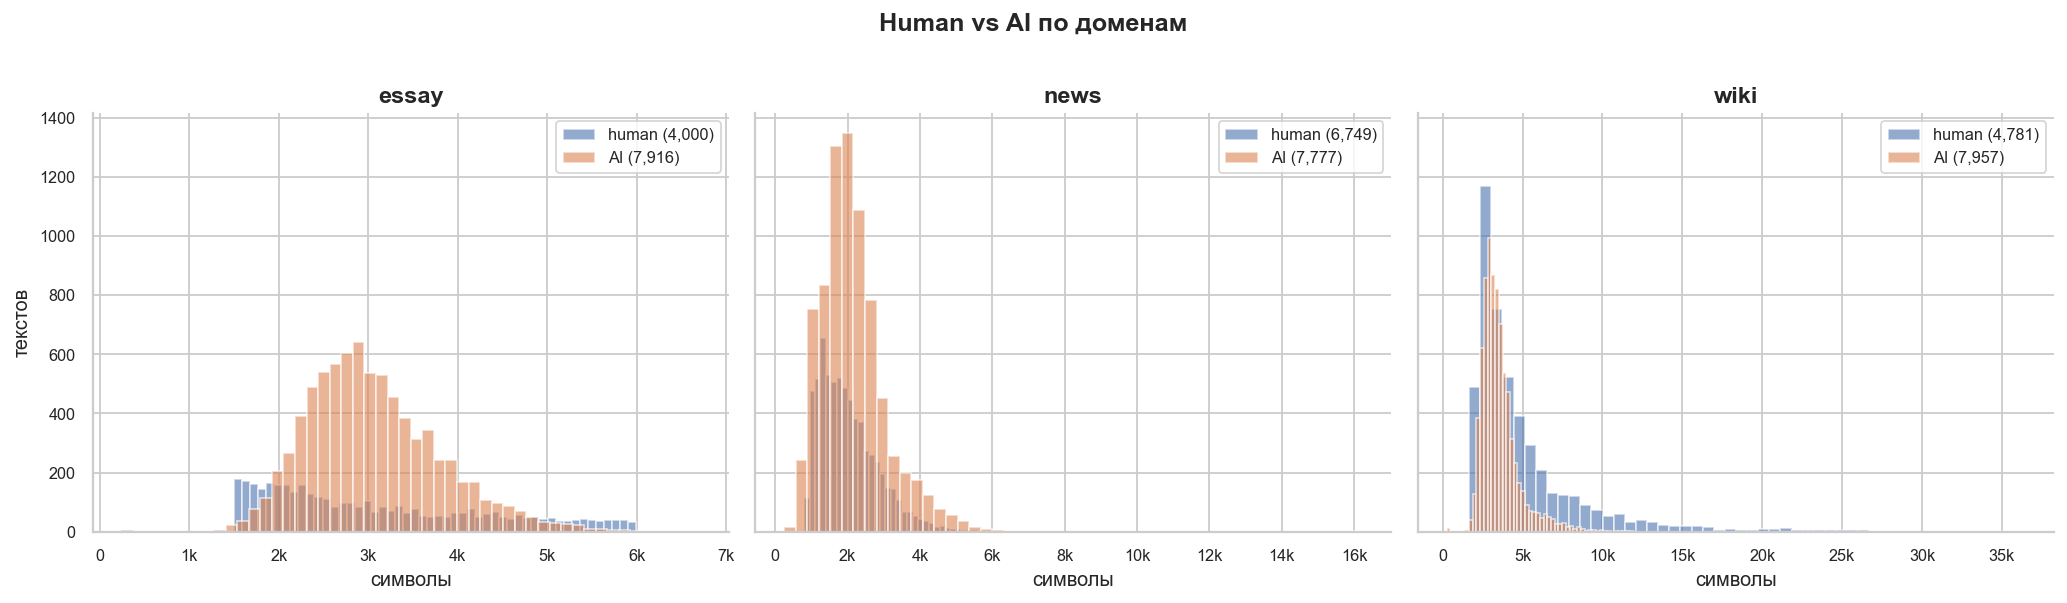

In [15]:
human_all = pd.concat(human_dfs.values(), ignore_index=True)
domains = sorted(set(human_all["domain"]) | set(gen_all["domain"]))

fig, axes = plt.subplots(1, len(domains), figsize=(16, 4.5), sharey=True)

for ax, dom in zip(axes, domains):
    h = human_all.loc[human_all["domain"] == dom, "_len"]
    a = gen_all.loc[gen_all["domain"] == dom, "_len"]
    ax.hist(h, bins=50, alpha=.6, label=f"human ({len(h):,})", color=C_HUMAN)
    ax.hist(a, bins=50, alpha=.6, label=f"AI ({len(a):,})",    color=C_AI)
    ax.set_title(dom)
    ax.set_xlabel("символы")
    ax.legend(frameon=True)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k" if x >= 1e3 else f"{x:.0f}"))

axes[0].set_ylabel("текстов")
fig.suptitle("Human vs AI по доменам", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [16]:
# выбросы по длине
SHORT, LONG = 300, 10_000

outliers = []
for name, df in all_named_dfs:
    n_short = (df["_len"] < SHORT).sum()
    n_long  = (df["_len"] > LONG).sum()
    if n_short or n_long:
        outliers.append({
            "источник": name,
            f"<{SHORT}": n_short, f">{LONG}": n_long,
            "всего": len(df),
            "% выбросов": round((n_short + n_long) / len(df) * 100, 2),
        })

if outliers:
    print(pd.DataFrame(outliers).to_string(index=False))
else:
    print("Выбросов нет.")

                           источник  <300  >10000  всего  % выбросов
                         human/wiki     0     419   4781        8.76
     gen/gemini-2.5-flash-lite_wiki     0      11    957        1.15
                 gen/GigaChat_essay     3       0   2000        0.15
                  gen/GigaChat_news    10       0   1999        0.50
                  gen/GigaChat_wiki     6       1   2000        0.35
   gen/llama-3.3-70b-versatile_news     0       1    999        0.10
adv/adversarial_paraphrase_GigaChat     3       0    508        0.59


AI-модели генерировали тексты с `target_chars`, поэтому разброс у них уже. Wiki содержит длинные статьи (часть >10k) - при токенизации они будут обрезаны. Тексты короче 300 символов не несут достаточного сигнала, их фильтруем.

note: порог 300 выбран приближено, возможно стоит попробовать 200 или 400 на валидации

## Покрытие доменов

In [17]:
all_main = pd.concat([human_all, gen_all], ignore_index=True)
pd.crosstab(all_main["source_name"], all_main["domain"], margins=True)

domain,essay,news,wiki,All
source_name,,,,
GigaChat,2000,1999,2000,5999
gemini-2.5-flash-lite,913,992,957,2862
habr,4000,0,0,4000
llama-3.3-70b-versatile,1000,999,1000,2999
taiga,0,6749,0,6749
wikipedia,0,0,4781,4781
yandexgpt,999,949,1000,2948
yandexgpt-lite,3004,2838,3000,8842
All,11916,14526,12738,39180


In [ ]:
expected_human = {("habr", "essay"), ("taiga", "news"), ("wikipedia", "wiki")}
expected_gen = {
    (m, d)
    for m in ["GigaChat", "gemini-2.5-flash-lite", "llama-3.3-70b-versatile", "yandexgpt-lite", "yandexgpt"]
    for d in ["essay", "news", "wiki"]
}
expected = expected_human | expected_gen
actual = set(zip(all_main["source_name"], all_main["domain"]))
missing = expected - actual

if missing:
    print(f"Отсутствуют: {sorted(missing)}")
else:
    print(f"Все {len(expected)} комбинаций source x domain на месте.")

Все 18 комбинаций source × domain на месте.


Каждый домен покрыт тремя human-источниками и пятью AI-моделями - перекоса нет. Adversarial идёт отдельно.

## Баланс моделей

In [ ]:
model_counts = gen_all.groupby(["source_name", "domain"]).size().unstack(fill_value=0)
model_counts["итого"] = model_counts.sum(axis=1)

totals = model_counts["итого"]
cv = totals.std() / totals.mean()
print(f"CV между моделями: {cv:.3f}  {"перекос" if cv > 0.15 else "норма"}")
print()
print(totals.sort_values(ascending=False).to_string())

CV между моделями: 0.561  ⚠ перекос

source_name
yandexgpt-lite             8842
GigaChat                   5999
llama-3.3-70b-versatile    2999
yandexgpt                  2948
gemini-2.5-flash-lite      2862


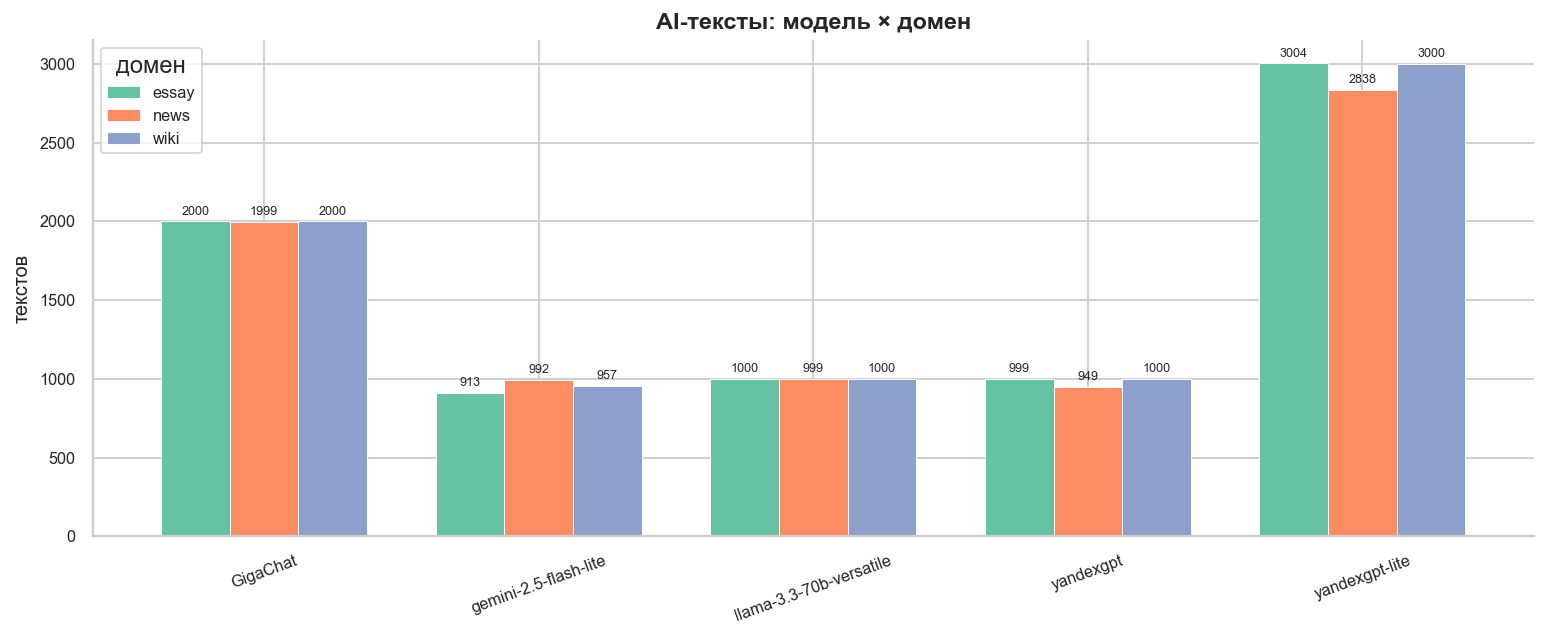

In [20]:
fig, ax = plt.subplots(figsize=(12, 5))
model_counts.drop(columns="итого").plot.bar(
    ax=ax, color=PAL_DOMAIN, edgecolor="white", lw=.5, width=.75)
ax.set_title("AI-тексты: модель × домен")
ax.set_xlabel("")
ax.set_ylabel("текстов")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="домен", frameon=True)
for c in ax.containers:
    ax.bar_label(c, fontsize=7, padding=2)
plt.tight_layout()
plt.show()

CV = 0.56 - yandexgpt-lite представлена втрое чаще gemini. При обучении нужен downsampling или взвешивание, иначе модель переобучится на доминирующий стиль.

Интересно, насколько это повлияет на recall по отдельным моделям - вернёмся к этому после первых экспериментов.

## Временной анализ

In [21]:
CHATGPT_LAUNCH = pd.Timestamp("2022-11-30", tz="UTC")

for name, df in human_dfs.items():
    if "created_at" not in df.columns:
        print(f"{name}: нет created_at")
        continue
    dates = pd.to_datetime(df["created_at"], errors="coerce", utc=True)
    n_valid = dates.notna().sum()
    n_null  = dates.isna().sum()
    post = (dates > CHATGPT_LAUNCH).sum()
    print(f"{name}: {n_valid:,} дат, {n_null:,} пропущено, после ChatGPT: {post}")

habr: 4,000 дат, 0 пропущено, после ChatGPT: 0
taiga: 4,419 дат, 2,330 пропущено, после ChatGPT: 0
wiki: 4,781 дат, 0 пропущено, после ChatGPT: 0


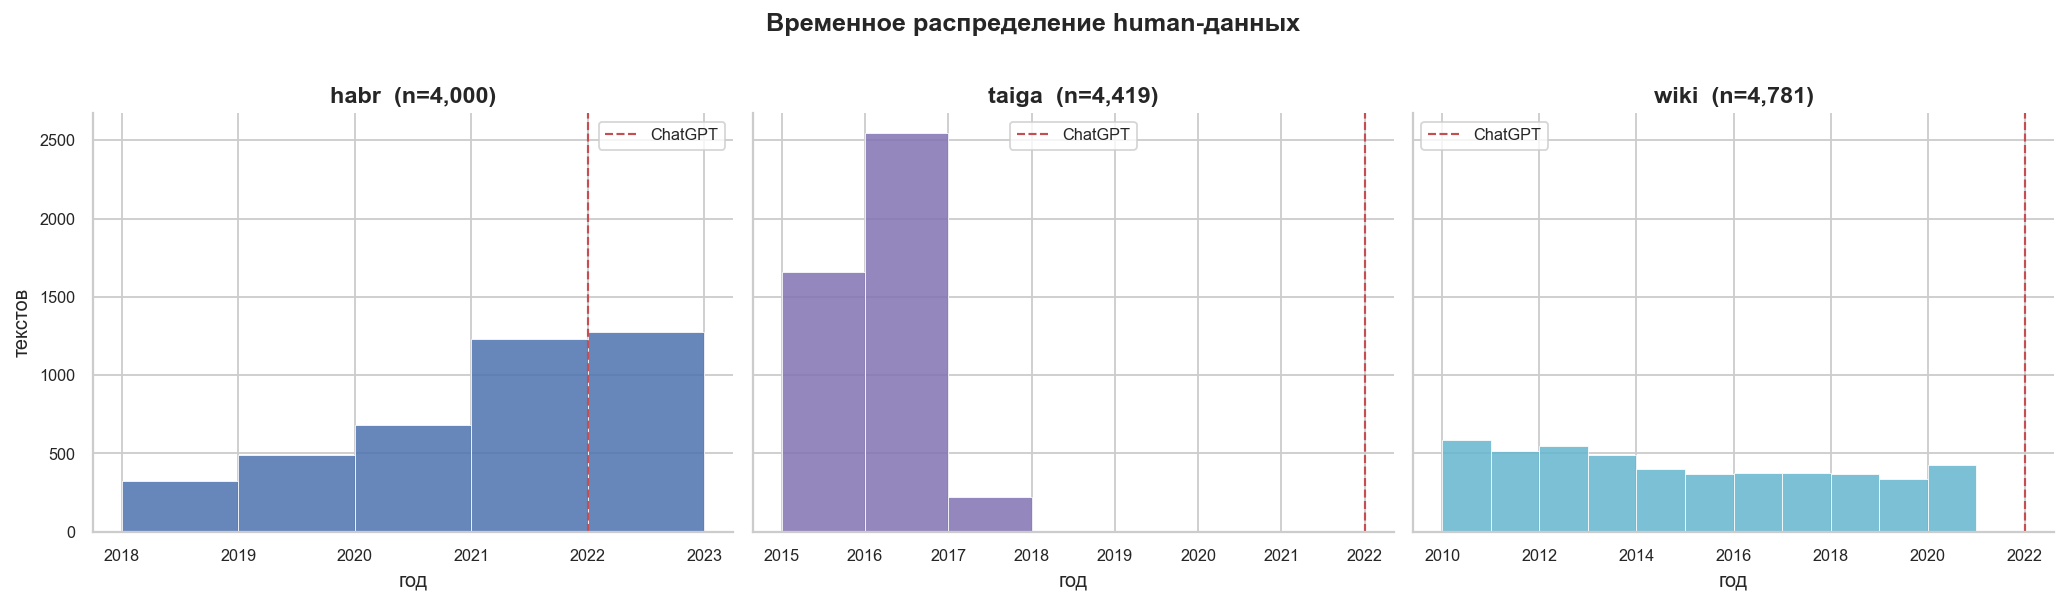

In [22]:
fig, axes = plt.subplots(1, len(human_dfs), figsize=(16, 4.5), sharey=True)
source_colors = {"habr": C_HUMAN, "taiga": "#8172B2", "wiki": "#64B5CD"}

for ax, (name, df) in zip(axes, human_dfs.items()):
    if "created_at" not in df.columns:
        ax.text(.5, .5, "нет дат", ha="center", va="center",
                transform=ax.transAxes, fontsize=12, color="grey")
        ax.set_title(name)
        continue
    dates = pd.to_datetime(df["created_at"], errors="coerce", utc=True).dropna()
    if dates.empty:
        ax.text(.5, .5, "все даты пустые", ha="center", va="center",
                transform=ax.transAxes, fontsize=12, color="grey")
        ax.set_title(name)
        continue
    ax.hist(dates.dt.year,
            bins=range(int(dates.dt.year.min()), int(dates.dt.year.max()) + 2),
            color=source_colors.get(name, C_HUMAN), edgecolor="white", lw=.5, alpha=.85)
    ax.axvline(2022, color=C_ALERT, ls="--", lw=1.2, label="ChatGPT")
    ax.set_title(f"{name}  (n={len(dates):,})")
    ax.set_xlabel("год")
    ax.legend(frameon=True)

axes[0].set_ylabel("текстов")
fig.suptitle("Временное распределение human-данных", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

Taiga (NPlus1) - 34.5% записей без даты. Wiki датирована по дате создания страницы. Habr-тексты после ноября 2022 - зона риска label noise, авторы могли использовать ChatGPT. В нашем случае таких текстов 0 - данные чисты.

## Выборочная проверка текстов

Случайные примеры из каждого класса.

In [ ]:
def show_samples(df: pd.DataFrame, label: str, n: int = 2, max_chars: int = 500):
    """Показывает случайные примеры текстов"""
    for i, (_, row) in enumerate(df.sample(min(n, len(df)), random_state=42).iterrows(), 1):
        text = row["text"][:max_chars] + ("…" if len(row["text"]) > max_chars else "")
        print(f"--- {label} | #{i} | {row.get('doc_id', '?')} | {len(row['text']):,} сим. ---")
        print(text)
        print()

In [24]:
for name, df in human_dfs.items():
    show_samples(df, f"human/{name}")

--- human/habr | #1 | habr_684732 | 1,966 сим. ---
Космический телескоп НАСА «Джеймс Уэбб» зафиксировал первые чёткие и подробные свидетельства присутствия углекислого газа в атмосфере экзопланеты, находящейся за пределами Солнечной системы. Экзопланета под наименованием WASP-39 b находится на расстоянии 700 световых лет от Земли и совершает оборот вокруг звезды-хозяина за четыре дня. WASP-39 b относится к типу «горячий Сатурн» и является одной из наименее плотных экзопланет из всех известных астрономам. Она обладает массой 0,28 массы Юпитера и …

--- human/habr | #2 | habr_594287 | 1,705 сим. ---
Химики НИУ «БелГУ» синтезировали биогенные частицы на основе серебра и золота, которые окажутся востребованными в качестве высокоэффективного катализатора и наносенсора.
Команда ученых БелГУ в сотрудничестве с исследователями из Вьетнама и Ирана разработали экологически безопасную и сравнительно недорогую в производстве технологию получения наночастиц серебра и золота при помощи гриба трутови

In [25]:
for key in list(gen_dfs)[:3]:
    show_samples(gen_dfs[key], f"gen/{key}", n=1)

--- gen/gemini-2.5-flash-lite_essay | #1 | ai_adbce0ed-3639-4c04-9646-2e6488d27cb9 | 4,891 сим. ---
## Этичность генетической модификации человека: на грани прогресса и ответственности

Генетическая модификация человека, некогда предмет научной фантастики, сегодня становится реальностью, открывая перед нами как головокружительные перспективы, так и глубокие этические дилеммы. Способность целенаправленно изменять наш генетический код – будь то для лечения наследственных заболеваний или для улучшения человеческих качеств – ставит перед обществом вопрос о границах допустимого. Я убежден, что, нес…

--- gen/gemini-2.5-flash-lite_news | #1 | ai_01c27d19-6961-4038-af09-54e2900a5834 | 2,776 сим. ---
В январе 2024 года стоимость фиксированного набора товаров, входящих в потребительскую корзину, выросла на 3,2% по сравнению с декабрем 2023 года. Об этом свидетельствуют данные Росстата, опубликованные 15 февраля. Ежемесячный рост цен на продовольственные товары составил 4,1%, что превысило прогн

In [26]:
for name, df in adv_dfs.items():
    show_samples(df, f"adv/{name}", n=1)

--- adv/adversarial_paraphrase_GigaChat | #1 | adv_2e1bf2c3-94b0-4a82-ba3a-bacb40e6f683 | 2,991 сим. ---
С развитием искусственного интеллекта перед журналистикой встаёт новый вызов – каким образом эта профессия изменится под влиянием современных технологий? Сегодняшний день приносит нам стремительные изменения в сфере информационных технологий, проникающих во все аспекты нашей жизни, включая медиаиндустрию.

Если раньше ИИ воспринимался лишь как вспомогательный инструмент, то сейчас он становится неотъемлемой частью профессиональной деятельности журналиста. Автоматизация рутинных задач позволяет о…

--- adv/adversarial_paraphrase_yandexgpt-lite | #1 | adv_41cb2a88-af6d-48d7-bb78-f7e24b041d67 | 2,601 сим. ---
В последнее время общественность была шокирована новостью об утечке персональных данных пользователей одной крупной компании. Этот инцидент вызвал широкий резонанс и заставил задуматься о масштабах проблемы. Злоумышленники получили доступ к конфиденциальной информации миллионов че

## Кодировочные артефакты

In [27]:
all_texts = pd.concat(
    [df.assign(_src=name) for name, df in {**human_dfs, **gen_dfs}.items()],
    ignore_index=True,
)

nbsp  = all_texts["text"].str.contains("\xa0", regex=False).sum()
nulls = all_texts["text"].str.contains("\x00", regex=False).sum()

print(f"NBSP (\\xa0): {nbsp}")
print(f"NULL (\\x00): {nulls}")
if nbsp == 0 and nulls == 0:
    print("Кодировка чистая.")

NBSP (\xa0): 0
NULL (\x00): 0
Кодировка чистая.


## Markdown-артефакты

Проверим утечку markdown. LLM генерируют текст с `##`, `**`, бэктиками - если это есть только в AI-текстах, модель получит тривиальный shortcut.

In [28]:
MD_PATTERNS = {
    "heading":  r"^#{1,3} ",
    "bold":     r"\*\*[^*]+\*\*",
    "code":     r"`[^`]+`",
    "ul":       r"^- ",
    "ol":       r"^\d+\. ",
}
_md_re = {k: re.compile(v, re.MULTILINE) for k, v in MD_PATTERNS.items()}


def has_markdown(text: str) -> bool:
    # note: можно считать долю markdown-символов, а не бинарный флаг
    return any(p.search(text) for p in _md_re.values())


# AI
rows = []
for name, df in gen_dfs.items():
    n_md = df["text"].apply(has_markdown).sum()
    rows.append({"файл": name, "с MD": n_md, "всего": len(df), "%": round(n_md / len(df) * 100, 1)})

md_stats = pd.DataFrame(rows).sort_values("%", ascending=False)
print(md_stats.to_string(index=False))
print()

# human baseline
for name, df in human_dfs.items():
    pct = df["text"].apply(has_markdown).mean() * 100
    print(f"human/{name}: {pct:.1f}%")

                         файл  с MD  всего    %
          yandexgpt-lite_wiki  2991   3000 99.7
               yandexgpt_wiki   986   1000 98.6
   gemini-2.5-flash-lite_wiki   922    957 96.3
                GigaChat_wiki  1865   2000 93.2
  gemini-2.5-flash-lite_essay   827    913 90.6
         yandexgpt-lite_essay  2568   3004 85.5
   gemini-2.5-flash-lite_news   846    992 85.3
          yandexgpt-lite_news  2226   2838 78.4
              yandexgpt_essay   718    999 71.9
               yandexgpt_news   629    949 66.3
                GigaChat_news  1224   1999 61.2
               GigaChat_essay  1148   2000 57.4
 llama-3.3-70b-versatile_wiki   140   1000 14.0
llama-3.3-70b-versatile_essay     0   1000  0.0
 llama-3.3-70b-versatile_news     0    999  0.0

human/habr: 0.4%
human/taiga: 0.0%
human/wiki: 0.1%


До 99.7% AI-текстов wiki-домена содержат markdown, у human - 0%. Это главный shortcut в данных. Перед обучением нужна очистка `strip_markdown`, иначе модель выучит форматирование вместо стилистики.

note: проверить после strip_markdown, не останется ли каких-нибудь unicode-кавычек или спецсимволов

## Абзацная структура

In [ ]:
human_all["_paras"] = human_all["text"].str.split(r"\n\s*\n").str.len()
gen_all["_paras"]   = gen_all["text"].str.split(r"\n\s*\n").str.len()

print("Абзацы (median / mean):")
print(f"human: {human_all['_paras'].median():.0f} / {human_all['_paras'].mean():.1f}")
print(f"AI:    {gen_all['_paras'].median():.0f} / {gen_all['_paras'].mean():.1f}")

Абзацы (median / mean):
  human: 1 / 1.0
  AI:    8 / 9.8


Human-тексты предобработаны, абзацы сглажены (median = 1). AI сохраняют `\n\n`, median = 8-9. Это второй shortcut после markdown. Нужно нормализовать `\n\n` для обоих классов, либо не включать `paragraph_count` в признаки.

note: не уверены, что простая нормализация \n\n не сломает структуру human-текстов - надо проверить на примерах

## Распределение тем

In [30]:
rows = []
for name, df in gen_dfs.items():
    if "meta" not in df.columns:
        continue
    topics = df["meta"].apply(lambda m: m.get("topic") if isinstance(m, dict) else None).dropna()
    if topics.empty:
        continue
    vc = topics.value_counts()
    rows.append({
        "файл": name,
        "домен": df["domain"].iloc[0],
        "тем": topics.nunique(),
        "min": vc.min(), "max": vc.max(), "mean": round(vc.mean(), 1),
    })

topic_df = pd.DataFrame(rows)
agg = topic_df.groupby("домен").agg(тем=("тем", "max"), min=("min", "min"), max=("max", "max"))
print("По доменам:")
print(agg.to_string())
print()
print("По файлам:")
print(topic_df.to_string(index=False))

По доменам:
       тем  min  max
домен               
essay   36   22   86
news    40    2   75
wiki    40   22   75

По файлам:
                         файл домен  тем  min  max  mean
  gemini-2.5-flash-lite_essay essay   36   22   27  25.4
   gemini-2.5-flash-lite_news  news   40   24   25  24.8
   gemini-2.5-flash-lite_wiki  wiki   40   22   25  23.9
               GigaChat_essay essay   36   54   57  55.6
                GigaChat_news  news   40   49   50  50.0
                GigaChat_wiki  wiki   40   50   50  50.0
llama-3.3-70b-versatile_essay essay   36   27   29  27.8
 llama-3.3-70b-versatile_news  news   40   24   25  25.0
 llama-3.3-70b-versatile_wiki  wiki   40   25   25  25.0
         yandexgpt-lite_essay essay   36   81   86  83.4
          yandexgpt-lite_news  news   39    2   75  72.8
          yandexgpt-lite_wiki  wiki   40   75   75  75.0
              yandexgpt_essay essay   36   27   28  27.8
               yandexgpt_news  news   38   24   25  25.0
               y

36-40 тем на домен, темы распределены ровно, перекоса нет. Интересно, сохранится ли это распределение после фильтрации коротких текстов.

## Оценка рисков

Сводная таблица - что может помешать обучению и что с этим делать.

In [ ]:
def assess_risks(df: pd.DataFrame) -> pd.DataFrame:
    """Проверяет основные риски датасета, возвращает таблицу."""
    risks = []

    # баланс классов
    if "label" in df.columns:
        minority = df["label"].value_counts(normalize=True).min()
        if minority < 0.3:
            risks.append(("Дисбаланс классов", f"minority={minority:.1%}", "HIGH",
                          "Stratified split + class weights + F1-macro"))
        elif minority < 0.4:
            risks.append(("Дисбаланс классов", f"minority={minority:.1%}", "MEDIUM",
                          "Stratified split, мониторить F1"))
        else:
            risks.append(("Дисбаланс классов", f"minority={minority:.1%}", "LOW", "OK"))

    # пропуски
    for col in ("text", "label"):
        if col in df.columns:
            pct = df[col].isna().mean()
            level = "HIGH" if pct > 0 else "LOW"
            risks.append((f"Пропуски {col}", f"{pct:.2%}", level,
                          "удалить" if pct > 0 else "OK"))

    # дубликаты
    if "text" in df.columns:
        dup = df.duplicated(subset=["text"]).mean()
        level = "HIGH" if dup > 0.01 else "MEDIUM" if dup > 0 else "LOW"
        risks.append(("Дубликаты", f"{dup:.2%}", level, "дедупликация"))

    # source → label shortcut
    if {"source_name", "label"} <= set(df.columns):
        from sklearn.metrics import mutual_info_score
        mi = mutual_info_score(df["source_name"], df["label"])
        risks.append(("source->label MI", f"{mi:.3f}", "INFO",
                      "не подавать source_name в модель"))

    # markdown shortcut
    if "text" in df.columns:
        _md = re.compile(r"^#{1,3}\s|\*\*[^*]+\*\*", re.MULTILINE)
        has = df["text"].apply(lambda t: bool(_md.search(str(t))))
        ai_pct = has[df["label"].isin(["ai", 1])].mean()
        hu_pct = has[df["label"].isin(["human", 0])].mean()
        if ai_pct - hu_pct > 0.3:
            risks.append(("Markdown shortcut", f"AI={ai_pct:.0%} / human={hu_pct:.0%}",
                          "HIGH", "strip_markdown"))

    # paragraph shortcut
    if "text" in df.columns:
        paras = df["text"].str.split(r"\n\n+").str.len()
        ai_med = paras[df["label"].isin(["ai", 1])].median()
        hu_med = paras[df["label"].isin(["human", 0])].median()
        if abs(ai_med - hu_med) > 3:
            risks.append(("Paragraph shortcut", f"AI={ai_med:.0f} / human={hu_med:.0f}",
                          "HIGH", "нормализовать \\n\\n"))

    return pd.DataFrame(risks, columns=["риск", "значение", "уровень", "рекомендация"])


# note: добавить проверку на длину текстов после фильтрации
main_df = pd.concat([df for n, df in all_named_dfs if not n.startswith("adv/")], ignore_index=True)
assess_risks(main_df)

,риск,значение,уровень,рекомендация
0,Дисбаланс классов,minority=39.6%,MEDIUM,"Stratified split, мониторить F1"
1,Пропуски text,0.00%,LOW,OK
2,Пропуски label,0.00%,LOW,OK
3,Дубликаты,0.06%,MEDIUM,дедупликация
4,source->label MI,0.672,INFO,не подавать source_name в модель
5,Markdown shortcut,AI=72% / human=0%,HIGH,strip_markdown
6,Paragraph shortcut,AI=8 / human=1,HIGH,нормализовать \n\n


## Итоги

In [32]:
total_h = sum(len(df) for df in human_dfs.values())
total_g = sum(len(df) for df in gen_dfs.values())
total_a = sum(len(df) for df in adv_dfs.values())
total   = total_h + total_g + total_a

print(f"Human:       {total_h:>6,}")
print(f"AI (gen):    {total_g:>6,}")
print(f"Adversarial: {total_a:>6,}")
print(f"Итого:       {total:>6,}")
print()
main = total_h + total_g
print(f"Баланс (без adv): human {total_h/main:.1%} / AI {total_g/main:.1%}")

Human:       15,530
AI (gen):    23,650
Adversarial:    516
Итого:       39,696

Баланс (без adv): human 39.6% / AI 60.4%


### Что получили

Все 21 файл загружены, обязательные поля на месте, пропусков нет. Adversarial-метки (`label=1` int) нужно привести к `"ai"`. Wiki содержит тексты >10k, тексты <300 сим. фильтруем.

Главная проблема - markdown shortcut: до 99.7% AI-текстов содержат markdown, у human 0%. Второй shortcut - абзацы (human median=1, AI median=8-9). Оба нужно чистить до обучения.

Баланс моделей: CV=0.56, перекос на yandexgpt-lite - нужен downsampling. Тем 36-40 на домен, label noise = 0.

note: попробовать MATTR вместо TTR для оценки лексического разнообразия

### для `assemble_dataset.py`

- [ ] Привести adversarial `label=1` к `"ai"`
- [ ] Фильтр по длине: <300 сим. отбросить
- [ ] `strip_markdown` для AI-текстов
- [ ] Нормализовать `\n\n`
- [ ] Downsampling моделей до ~3k на каждую
- [ ] Adversarial - только test-split


Очистка реализована в text_cleaning.py (31 тест), сборка в assemble_dataset.py (topic-aware split, holdout, adversarial), верификация в test_splits.py (28 тестов, markdown=0, leakage=0).

In [33]:
print("Аудит завершён.")

Аудит завершён.
